# Analysis NN:

In [ ]:
library(data.table)
library(dplyr)



Attaching package: 'dplyr'

The following objects are masked from 'package:data.table':

    between, first, last

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

# Overview

Calculate quantitative inhibition metrics from GWA data

In [ ]:
pheno_path <- "data/processed/phenotypes/pheno.df.rda"

# toxicant condition metadata
tox_meta_fn <- "data/processed/tox_data/tox_metadata.csv"


# Inputs

Load the phenotype data

In [ ]:
# load phenotype data
load(pheno_path)

dplyr::glimpse(pheno.df)


Rows: 53,302
Columns: 50
$ Assay_Bleach                   <chr> "GWA01B_1", "GWA01B_1", "GWA01B_1", "GW…
$ Metadata_Plate                 <chr> "p004", "p004", "p004", "p004", "p004",…
$ Metadata_Well                  <chr> "A05", "A07", "A11", "B01", "B02", "B03…
$ drug                           <chr> "Carboxin", "Carboxin", "Carboxin", "Ca…
$ strain                         <chr> "NIC252", "NIC252", "ECA2551", "DL226",…
$ mean_wormlength_um             <dbl> 515.8143, 432.6405, 513.2523, 607.3552,…
$ min_wormlength_um              <dbl> 171.6436, 213.0974, 172.7738, 565.3294,…
$ q10_wormlength_um              <dbl> 301.7215, 260.9289, 196.3891, 576.7805,…
$ q25_wormlength_um              <dbl> 398.1871, 350.8718, 443.4702, 590.4763,…
$ median_wormlength_um           <dbl> 553.9212, 425.0989, 548.5015, 603.5669,…
$ sd_wormlength_um               <dbl> 212.55297, 147.44451, 216.46186, 36.137…
$ q75_wormlength_um              <dbl> 652.3901, 529.6366, 654.2791, 610.4924,…
$ q90_wormlengt

Load the toxicant metadata (for nice_drug_label2)

In [ ]:
tox_meta <- data.table::fread(tox_meta_fn)
dplyr::glimpse(tox_meta)


Rows: 26
Columns: 21
$ toxicant         <chr> "2,4-D", "Aldicarb", "Arsenic", "Atrazine", "Cadmium …
$ cas              <int> 94757, 116063, 1327533, 1912249, 10108642, 63252, 523…
$ cat_num          <chr> "31518-250MG", "33386-100MG", "202673-5G", "45330-250…
$ source           <chr> "sigma", "sigma", "sigma", "sigma", "sigma", "sigma",…
$ storage_temp     <int> -20, -20, -20, -20, -20, -20, -20, -20, -20, -20, -20…
$ stock_mM         <int> 500, 2000, 450, 500, 500, 500, 1000, 500, 75, 100, 50…
$ diluent          <chr> "DMSO", "DMSO", "Water", "DMSO", "Water", "DMSO", "DM…
$ DTXSID           <chr> "DTXSID0020442", "DTXSID0039223", "DTXSID0020103", "D…
$ PREFERRED_NAME   <chr> "2,4-Dichlorophenoxyacetic acid", "Aldicarb", "Arseni…
$ CASRN            <chr> "94-75-7", "116-06-3", "1327-53-3", "1912-24-9", "101…
$ drug             <chr> "2_4-D", "Aldicarb", "Arsenic trioxide", "Atrazine", …
$ nice_drug_label2 <chr> "2,4-D", "Aldicarb", "Arsenic", "Atrazine", "Cadmium"…
$ nice_drug_label  

Extract the relevant columns: \* `median_wormlength_um`: Median wormlenght for a well \* `drug`: Toxicant \* `strain`: Strain name \* `control_pheno`: The control phenotype for that strain \* `well.id`: The well identifier

In [ ]:
clean_pheno_df <- pheno.df %>%
  dplyr::select(
    drug,
    strain,
    median_wormlength_um,
    control_pheno,
    well.id
  ) 


# Validate the data

These data contain well-level estimates of toxicant responses. For each unique `strain`, we expected to 26 or fewer unique `drug` values, and 12 wells per `drug`/`strain` combination

In [ ]:
strain_drug_counts <- clean_pheno_df %>%
  dplyr::group_by(strain) %>%
  dplyr::summarise(
    n_drugs = dplyr::n_distinct(drug),
    .groups = "drop"
  )
knitr::kable(head(strain_drug_counts))


  strain       n_drugs
  ---------- ---------
  AB1               26
  BRC20263          26
  CB4854            26
  CB4855            26
  CB4856            26
  CB4857            26


Check the number of unique drugs per strain and the number of unique control well phenotypes per strain/drug combination

In [ ]:
validation_summary <- clean_pheno_df %>%
  dplyr::group_by(strain, drug, .drop = FALSE) %>%
  dplyr::summarise(
    n_wells = dplyr::n_distinct(well.id),
    n_distinct_control_pheno = dplyr::n_distinct(control_pheno),
    .groups = "drop"
  )

knitr::kable(head(validation_summary))


  strain   drug                   n_wells   n_distinct_control_pheno
  -------- -------------------- --------- --------------------------
  AB1      2_4-D                        4                          2
  AB1      Aldicarb                     8                          2
  AB1      Arsenic trioxide             8                          2
  AB1      Atrazine                     8                          2
  AB1      Cadmium dichloride           7                          2
  AB1      Carbaryl                     7                          2


# Calculate inhibition metrics

## Step 1: Calculate % growth inhibition for each well (rowwise)

Calculate the percent growth inhibition for each well using the paired `control_pheno` value. The calculation is performed rowwise to preserve the pairing between each toxicant measurement and its corresponding control phenotype.

Formula: `% growth inhibition = 100 × (1 – (median_wormlength_um / control_pheno))`

In [ ]:
well_inhibition <- clean_pheno_df %>%
  dplyr::mutate(
    pct_growth_inhibition = 100 * (1 - (median_wormlength_um / control_pheno))
  )

dplyr::glimpse(well_inhibition)


Rows: 53,302
Columns: 6
$ drug                  <chr> "Carboxin", "Carboxin", "Carboxin", "Carboxin", …
$ strain                <chr> "NIC252", "NIC252", "ECA2551", "DL226", "DL226",…
$ median_wormlength_um  <dbl> 553.9212, 425.0989, 548.5015, 603.5669, 573.7603…
$ control_pheno         <dbl> 697.2765, 697.2765, 775.6277, 747.1132, 747.1132…
$ well.id               <chr> "GWA01B_1_p004_A05", "GWA01B_1_p004_A07", "GWA01…
$ pct_growth_inhibition <dbl> 20.55931, 39.03439, 29.28290, 19.21346, 23.20303…

## Step 2: Summarize % growth inhibition per strain/toxicant

For each strain in each toxicant condition, calculate the mean % growth inhibition across all wells. Also report the number of distinct `control_pheno` values and wells per strain/drug combination.

In [ ]:
strain_inhibition <- well_inhibition %>%
  dplyr::group_by(drug, strain) %>%
  dplyr::summarise(
    pct_growth_inhibition = mean(pct_growth_inhibition, na.rm = TRUE),
    mean_length_exposed = mean(median_wormlength_um, na.rm = TRUE),
    mean_control_pheno = mean(control_pheno, na.rm = TRUE),
    n_control_pheno_values = dplyr::n_distinct(control_pheno),
    n_wells = dplyr::n(),
    .groups = "drop"
  )


In [ ]:
knitr::kable(head(strain_inhibition))


  ------------------------------------------------------------------------------------------------------------------------
  drug    strain       pct_growth_inhibition   mean_length_exposed   mean_control_pheno   n_control_pheno_values   n_wells
  ------- ---------- ----------------------- --------------------- -------------------- ------------------------ ---------
  2_4-D   AB1                      14.937665              680.9376             800.5584                        2         4

  2_4-D   BRC20263                 18.210414              691.4159             845.3166                        3        11

  2_4-D   CB4854                    1.599414              674.6536             685.7091                        3         9

  2_4-D   CB4855                   26.607157              568.8933             775.4930                        3        12

  2_4-D   CB4856                    8.513170              761.1933             832.2282                       28       100

  2_4-D   CB4857                   25.475130              559.5617             750.9665                        3        11
  ------------------------------------------------------------------------------------------------------------------------


Report the distribution of distinct control phenotype values per strain/drug:

In [ ]:
knitr::kable(as.data.frame(table(strain_inhibition$n_control_pheno_values)),
             col.names = c("n_control_pheno_values", "Frequency"))


  n_control_pheno_values     Frequency
  ------------------------ -----------
  1                                 72
  2                                792
  3                               3863
  19                                 1
  20                                 5
  21                                 1
  22                                 2
  23                                 3
  24                                 2
  25                                 6
  26                                10
  27                                 9
  28                                16
  29                                41
  30                                 8


Preview the distribution of inhibition values across all strain/toxicant combinations:

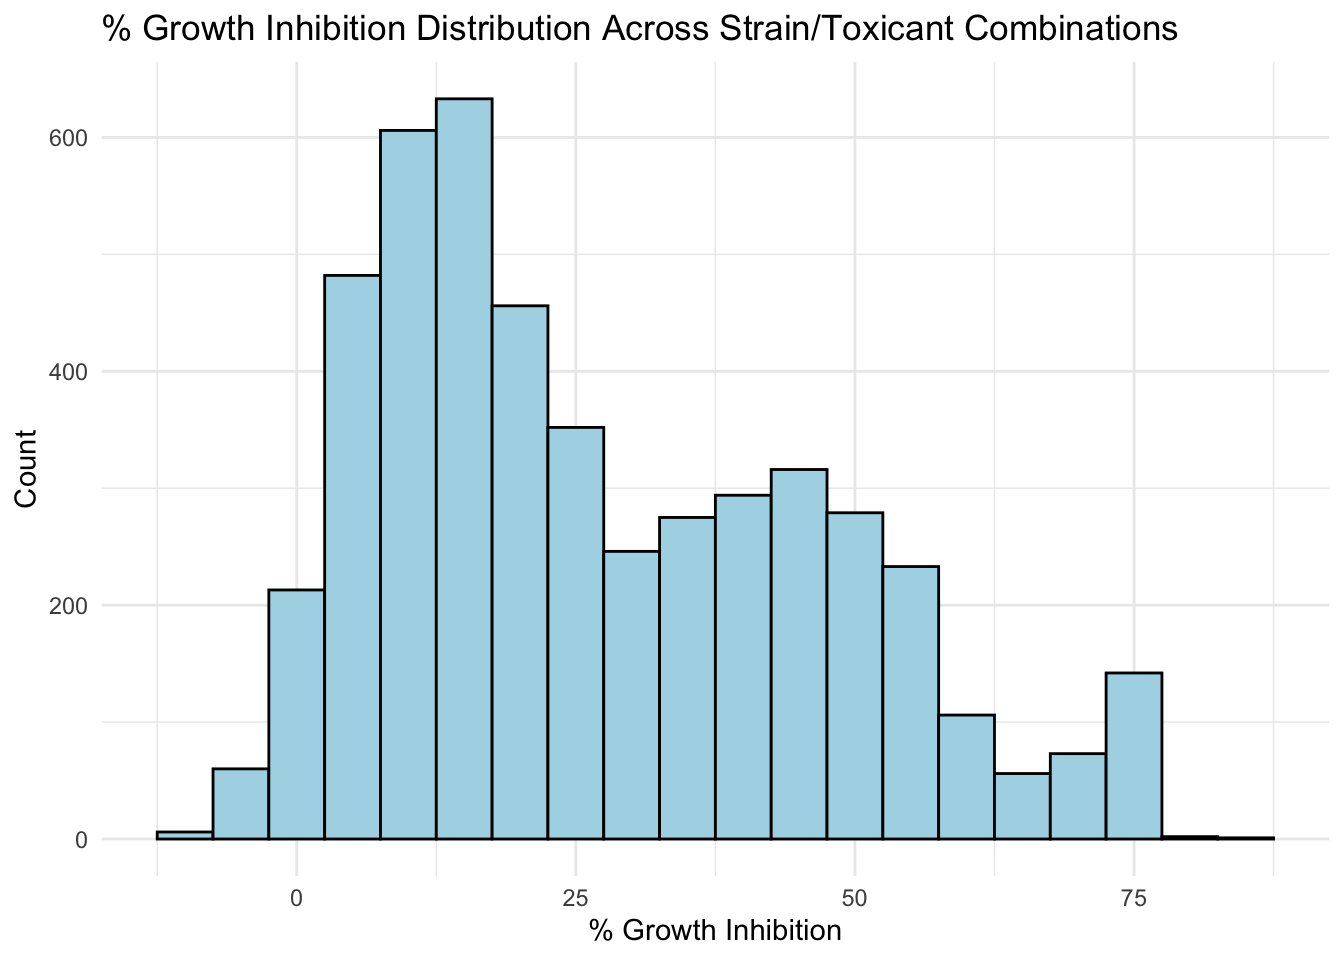

In [ ]:
ggplot2::ggplot(strain_inhibition, ggplot2::aes(x = pct_growth_inhibition)) +
  ggplot2::geom_histogram(binwidth = 5, fill = "lightblue", color = "black") +
  ggplot2::theme_minimal() +
  ggplot2::labs(
    title = "% Growth Inhibition Distribution Across Strain/Toxicant Combinations",
    x = "% Growth Inhibition",
    y = "Count"
  )


In [ ]:
summary(strain_inhibition$pct_growth_inhibition)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -10.25   11.25   22.00   27.14   42.51   82.72 

## Step 3: Summarize % growth inhibition per toxicant condition (mean ± SD across strains)

For each toxicant, calculate the mean and standard deviation of % growth inhibition across all strains used in the GWAS.

In [ ]:
toxicant_inhibition_summary <- strain_inhibition %>%
  dplyr::group_by(drug) %>%
  dplyr::summarise(
    mean_pct_inhibition = mean(pct_growth_inhibition, na.rm = TRUE),
    sd_pct_inhibition = sd(pct_growth_inhibition, na.rm = TRUE),
    n_strains = dplyr::n(),
    .groups = "drop"
  )

dplyr::glimpse(toxicant_inhibition_summary)


Rows: 26
Columns: 4
$ drug                <chr> "2_4-D", "Aldicarb", "Arsenic trioxide", "Atrazine…
$ mean_pct_inhibition <dbl> 12.745115, 20.175603, 18.825557, 25.379822, 54.052…
$ sd_pct_inhibition   <dbl> 11.454246, 12.629435, 5.593553, 5.362616, 7.516715…
$ n_strains           <int> 192, 194, 194, 195, 190, 194, 193, 152, 194, 173, …

Display the summary table:

In [ ]:
knitr::kable(toxicant_inhibition_summary %>% dplyr::arrange(desc(mean_pct_inhibition)))


  ------------------------------------------------------------------------------
  drug                       mean_pct_inhibition   sd_pct_inhibition   n_strains
  ------------------------ --------------------- ------------------- -----------
  Silver nitrate_250                   73.428172            2.685455         186

  Chlorfenapyr                         56.478998            8.111245         152

  Cadmium dichloride                   54.052882            7.516715         190

  Triphenyl phosphate_50               52.099167            4.796870         191

  Methyl mercury                       47.632158           11.537076         193

  Paraquat_250                         44.801430            2.718831         192

  Methomyl                             43.443289            7.826127         143

  Pyraclostrobin                       38.479562            4.241142         194

  Malathion                            37.746505            7.035962         194

  Copper chloride                      30.396514           15.670375         194

  Paraquat_62.5                        29.075983            8.004260         155

  Atrazine                             25.379822            5.362616         195

  Aldicarb                             20.175603           12.629435         194

  Carboxin                             18.901134            8.567646         193

  Arsenic trioxide                     18.825557            5.593553         194

  Chlorpyrifos                         17.834664            6.767356         173

  Triphenyl phosphate_6.25             14.395304            4.656814         175

  Carbaryl                             14.357044            7.324310         194

  Chlorothalonil                       13.872995            4.899767         194

  2_4-D                                12.745115           11.454246         192

  Nickel dichloride                    11.261563           13.982614         193

  Zinc dichloride                      11.032943            4.898762         174

  Lead nitrate                          9.068888            3.465213         194

  Silver nitrate_7.8                    8.785550            6.105950         194

  Mancozeb                              8.485122            4.807222         194

  Propoxur                              2.856540            4.194662         194
  ------------------------------------------------------------------------------


## Step 4: Join with toxicant metadata for nice_drug_label2

Join the inhibition summary with the toxicant metadata to include the `nice_drug_label2` values for integration with Figure 2.

In [ ]:
# Select drug and nice_drug_label2 from toxicant metadata
drug_labels <- tox_meta %>%
  dplyr::select(drug, nice_drug_label2) %>%
  dplyr::distinct()

# Join with inhibition summary
toxicant_inhibition_final <- toxicant_inhibition_summary %>%
  dplyr::left_join(drug_labels, by = "drug") %>%
  # Clean up nice_drug_label2 to replace uM with µM for plotting
  dplyr::mutate(nice_drug_label2 = stringr::str_replace(nice_drug_label2, pattern = "uM", replacement = "µM"))

dplyr::glimpse(toxicant_inhibition_final)


Rows: 26
Columns: 5
$ drug                <chr> "2_4-D", "Aldicarb", "Arsenic trioxide", "Atrazine…
$ mean_pct_inhibition <dbl> 12.745115, 20.175603, 18.825557, 25.379822, 54.052…
$ sd_pct_inhibition   <dbl> 11.454246, 12.629435, 5.593553, 5.362616, 7.516715…
$ n_strains           <int> 192, 194, 194, 195, 190, 194, 193, 152, 194, 173, …
$ nice_drug_label2    <chr> "2,4-D", "Aldicarb", "Arsenic", "Atrazine", "Cadmi…

In [ ]:
knitr::kable(toxicant_inhibition_final %>% dplyr::arrange(desc(mean_pct_inhibition)))


  --------------------------------------------------------------------------------------------
  drug                  mean_pct_inhibition   sd_pct_inhibition   n_strains nice_drug_label2
  ------------------- --------------------- ------------------- ----------- ------------------
  Silver nitrate_250              73.428172            2.685455         186 Silver 250 µM

  Chlorfenapyr                    56.478998            8.111245         152 Chlorfenapyr

  Cadmium dichloride              54.052882            7.516715         190 Cadmium

  Triphenyl                       52.099167            4.796870         191 TPhP 50 µM
  phosphate_50                                                              

  Methyl mercury                  47.632158           11.537076         193 Mercury

  Paraquat_250                    44.801430            2.718831         192 Paraquat 250 µM

  Methomyl                        43.443289            7.826127         143 Methomyl

  Pyraclostrobin                  38.479562            4.241142         194 Pyraclostrobin

  Malathion                       37.746505            7.035962         194 Malathion

  Copper chloride                 30.396514           15.670375         194 Copper

  Paraquat_62.5                   29.075983            8.004260         155 Paraquat 62.5 µM

  Atrazine                        25.379822            5.362616         195 Atrazine

  Aldicarb                        20.175603           12.629435         194 Aldicarb

  Carboxin                        18.901134            8.567646         193 Carboxin

  Arsenic trioxide                18.825557            5.593553         194 Arsenic

  Chlorpyrifos                    17.834664            6.767356         173 Chlorpyrifos

  Triphenyl                       14.395304            4.656814         175 TPhP 6.25 µM
  phosphate_6.25                                                            

  Carbaryl                        14.357044            7.324310         194 Carbaryl

  Chlorothalonil                  13.872995            4.899767         194 Chlorothalonil

  2_4-D                           12.745115           11.454246         192 2,4-D

  Nickel dichloride               11.261563           13.982614         193 Nickel

  Zinc dichloride                 11.032943            4.898762         174 Zinc

  Lead nitrate                     9.068888            3.465213         194 Lead

  Silver nitrate_7.8               8.785550            6.105950         194 Silver 7.8 µM

  Mancozeb                         8.485122            4.807222         194 Mancozeb

  Propoxur                         2.856540            4.194662         194 Propoxur
  --------------------------------------------------------------------------------------------


# Save output

Save the toxicant inhibition summary for use in Figure 2.

In [ ]:
output_path <- "data/processed/phenotypes/toxicant_inhibition_summary.csv"
data.table::fwrite(toxicant_inhibition_final, output_path)
message("Saved toxicant inhibition summary to: ", output_path)


Saved toxicant inhibition summary to: data/processed/phenotypes/toxicant_inhibition_summary.csv